In [ ]:
!unzip '/content/_edges.zip'
!unzip '/content/_rgb.zip'
!unzip '/content/_keypoints.zip'

In [3]:
import os
import random
from pathlib import Path
from dataclasses import dataclass, field

import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.models as models
from torchvision import transforms
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report
)

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
DATA_ROOT = Path("/content")
RGB_DIR = DATA_ROOT / "_rgb"
EDGE_DIR = DATA_ROOT / "_edges"
SKELETON_DIR = DATA_ROOT / "_keypoints"

BATCH_SIZE = 32
IMG_SIZE = 224

rgb_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])
edge_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])
skeleton_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

## dataset pipeline

In [6]:
@dataclass
class PairedSample:
    rgb_path: str
    edge_path: str
    skeleton_path: str
    label: int


def _index_by_stem(class_dir: Path) -> dict:
    return {p.stem: p for p in class_dir.iterdir() if p.is_file()}


def build_paired_index(rgb_dir: Path, edge_dir: Path, skeleton_dir: Path):
    classes = sorted(
        d.name for d in rgb_dir.iterdir() if d.is_dir()
    )
    # same class set on all three modalities
    for other, name in [(edge_dir, "edge"), (skeleton_dir, "skeleton")]:
        other_classes = sorted(d.name for d in other.iterdir() if d.is_dir())
        assert other_classes == classes, (
            f"Class folders differ between rgb and {name}: "
            f"{set(classes) ^ set(other_classes)}"
        )

    samples = []
    dropped = 0
    for label_idx, cls in enumerate(classes):
        rgb_map = _index_by_stem(rgb_dir / cls)
        edge_map = _index_by_stem(edge_dir / cls)
        skel_map = _index_by_stem(skeleton_dir / cls)

        common_stems = set(rgb_map) & set(edge_map) & set(skel_map)
        dropped += len(set(rgb_map) | set(edge_map) | set(skel_map)) - len(common_stems)

        for stem in sorted(common_stems):
            samples.append(PairedSample(
                rgb_path=str(rgb_map[stem]),
                edge_path=str(edge_map[stem]),
                skeleton_path=str(skel_map[stem]),
                label=label_idx,
            ))

    if dropped:
        print(f"[build_paired_index] Dropped {dropped} unmatched files "
              f"(present in some but not all three views).")
    return samples, classes


class PairedMultiViewDataset(Dataset):
    # Returns (rgb_tensor, edge_tensor, skeleton_tensor, label) for one
    def __init__(self, samples, classes):
        self.samples = samples
        self.classes = classes

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        rgb_img = rgb_transform(Image.open(s.rgb_path).convert("RGB"))
        edge_img = edge_transform(Image.open(s.edge_path).convert("L"))
        skel_img = skeleton_transform(Image.open(s.skeleton_path).convert("RGB"))
        return rgb_img, edge_img, skel_img, s.label

In [7]:
# to avoid data lekage , while fine-tuning models
def stratified_split(samples, val_frac=0.15, test_frac=0.15, seed=SEED):
    rng = random.Random(seed)
    by_class = {}
    for i, s in enumerate(samples):
        by_class.setdefault(s.label, []).append(i)

    train_idx, val_idx, test_idx = [], [], []
    for label, idxs in by_class.items():
        idxs = idxs[:]
        rng.shuffle(idxs)
        n = len(idxs)
        n_val = max(1, int(n * val_frac))
        n_test = max(1, int(n * test_frac))
        val_idx += idxs[:n_val]
        test_idx += idxs[n_val:n_val + n_test]
        train_idx += idxs[n_val + n_test:]

    rng.shuffle(train_idx)
    return train_idx, val_idx, test_idx

In [8]:
samples, classes = build_paired_index(RGB_DIR, EDGE_DIR, SKELETON_DIR)
num_classes = len(classes)
print(f"{len(samples)} aligned samples across {num_classes} classes.")

dataset = PairedMultiViewDataset(samples, classes)
train_idx, val_idx, test_idx = stratified_split(samples)

[build_paired_index] Dropped 1370 unmatched files (present in some but not all three views).
1145 aligned samples across 36 classes.


In [9]:
train_loader = DataLoader(Subset(dataset, train_idx), batch_size=BATCH_SIZE,
                            shuffle=True, drop_last=True)
val_loader = DataLoader(Subset(dataset, val_idx), batch_size=BATCH_SIZE,
                          shuffle=False)
test_loader = DataLoader(Subset(dataset, test_idx), batch_size=BATCH_SIZE,
                          shuffle=False)

In [10]:
def build_branch(num_classes: int, in_channels: int = 3) -> nn.Module:
    m = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V1)
    if in_channels != 3:
        m.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2,
                             padding=3, bias=False)
    in_features = m.fc.in_features
    m.fc = nn.Linear(in_features, num_classes)
    return m

## Average Weight

In [11]:
def run_epoch(models_dict, optimizers, loader, criterion, train: bool):
    for m in models_dict.values():
        m.train(mode=train)

    stats = {k: {"loss": 0.0, "correct": 0} for k in models_dict}
    n = 0

    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for rgb, edge, skel, labels in tqdm(loader, desc="train" if train else "eval"):
            rgb, edge, skel, labels = (
                rgb.to(device), edge.to(device), skel.to(device), labels.to(device)
            )
            inputs = {"rgb": rgb, "edge": edge, "skeleton": skel}
            n += labels.size(0)

            for name, model in models_dict.items():
                if train:
                    optimizers[name].zero_grad()
                logits = model(inputs[name])
                loss = criterion(logits, labels)
                if train:
                    loss.backward()
                    optimizers[name].step()
                stats[name]["loss"] += loss.item() * labels.size(0)
                stats[name]["correct"] += (logits.argmax(1) == labels).sum().item()

    return {
        name: {"loss": s["loss"] / n, "acc": s["correct"] / n}
        for name, s in stats.items()
    }


def train_branches(models_dict, train_loader, val_loader, epochs=10,
                    lr=1e-4, patience=3, ckpt_dir="checkpoints"):
    os.makedirs(ckpt_dir, exist_ok=True)
    criterion = nn.CrossEntropyLoss()
    optimizers = {
        name: torch.optim.AdamW(m.parameters(), lr=lr)
        for name, m in models_dict.items()
    }
    best_val_acc = {name: 0.0 for name in models_dict}
    epochs_no_improve = {name: 0 for name in models_dict}
    stopped = {name: False for name in models_dict}

    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")
        train_stats = run_epoch(models_dict, optimizers, train_loader, criterion, train=True)
        val_stats = run_epoch(models_dict, optimizers, val_loader, criterion, train=False)

        for name in models_dict:
            print(f"  [{name}] train_loss={train_stats[name]['loss']:.4f} "
                  f"train_acc={train_stats[name]['acc']:.4f} | "
                  f"val_loss={val_stats[name]['loss']:.4f} "
                  f"val_acc={val_stats[name]['acc']:.4f}")

            if val_stats[name]["acc"] > best_val_acc[name]:
                best_val_acc[name] = val_stats[name]["acc"]
                epochs_no_improve[name] = 0
                torch.save(models_dict[name].state_dict(),
                           os.path.join(ckpt_dir, f"{name}_best.pt"))
            else:
                epochs_no_improve[name] += 1
                if epochs_no_improve[name] >= patience:
                    stopped[name] = True

        if all(stopped.values()):
            print("All branches early-stopped.")
            break

    # reload best checkpoints
    for name, m in models_dict.items():
        m.load_state_dict(torch.load(os.path.join(ckpt_dir, f"{name}_best.pt")))
    return models_dict, best_val_acc

In [12]:
models_dict = {
    "rgb": build_branch(num_classes, in_channels=3).to(device),
    "edge": build_branch(num_classes, in_channels=1).to(device),
    "skeleton": build_branch(num_classes, in_channels=3).to(device),
}

models_dict, best_val_acc = train_branches(
    models_dict, train_loader, val_loader, epochs=10, lr=1e-4, patience=3
)
print("\nBest per-branch val accuracy:", best_val_acc)

Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:01<00:00, 123MB/s]



Epoch 1/10


eval: 100%|██████████| 5/5 [00:03<00:00,  1.32it/s]


  [rgb] train_loss=2.1458 train_acc=0.5887 | val_loss=1.0675 val_acc=0.8302
  [edge] train_loss=2.6251 train_acc=0.3875 | val_loss=3.3418 val_acc=0.0440
  [skeleton] train_loss=2.2657 train_acc=0.5450 | val_loss=1.5867 val_acc=0.7421

Epoch 2/10


...

  [rgb] train_loss=0.0068 train_acc=1.0000 | val_loss=0.1766 val_acc=0.9623
  [edge] train_loss=0.0317 train_acc=0.9962 | val_loss=0.2990 val_acc=0.8994
  [skeleton] train_loss=0.0187 train_acc=0.9988 | val_loss=0.1959 val_acc=0.9434

Epoch 9/10


eval: 100%|██████████| 5/5 [00:03<00:00,  1.32it/s]


  [rgb] train_loss=0.0063 train_acc=1.0000 | val_loss=0.1736 val_acc=0.9560
  [edge] train_loss=0.0287 train_acc=1.0000 | val_loss=0.2941 val_acc=0.9371
  [skeleton] train_loss=0.0111 train_acc=1.0000 | val_loss=0.1811 val_acc=0.9434

Epoch 10/10


eval: 100%|██████████| 5/5 [00:04<00:00,  1.20it/s]


  [rgb] train_loss=0.0052 train_acc=1.0000 | val_loss=0.1770 val_acc=0.9623
  [edge] train_loss=0.0229 train_acc=0.9975 | val_loss=0.3443 val_acc=0.8994
  [skeleton] train_loss=0.0077 train_acc=1.0000 | val_loss=0.1924 val_acc=0.9497

Best per-branch val accuracy: {'rgb': 0.9685534591194969, 'edge': 0.9371069182389937, 'skeleton': 0.949685534591195}


In [13]:
def evaluate_predictions(preds: np.ndarray, labels: np.ndarray, name: str,
                          class_names=None, plot_cm=False):
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    print(f"{name:>28s} | acc={acc:.4f}  macro-F1={f1:.4f}")
    if plot_cm and class_names is not None:
        cm = confusion_matrix(labels, preds)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=False, cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names)
        plt.title(name)
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()
        print(classification_report(labels, preds, target_names=class_names))
    return acc, f1


def average_logits_fusion(test_logits: dict) -> np.ndarray:
    stacked = torch.stack(list(test_logits.values()), dim=0)  # [n_models, N, C]
    probs = F.softmax(stacked, dim=-1).mean(dim=0)
    return probs.argmax(1).numpy()


def confidence_weighted_fusion(test_logits: dict) -> np.ndarray:
    probs_per_branch = [F.softmax(v, dim=-1) for v in test_logits.values()]
    confidences = [p.max(dim=-1, keepdim=True).values for p in probs_per_branch]
    weights = torch.stack(confidences, dim=0)
    weights = weights / weights.sum(dim=0, keepdim=True)  # normalize across branches
    stacked_probs = torch.stack(probs_per_branch, dim=0)
    fused = (weights * stacked_probs).sum(dim=0)
    return fused.argmax(1).numpy()

## Meta-learner

In [14]:
class MetaLearner(nn.Module):
    def __init__(self, num_branches: int, num_classes: int, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(num_branches * num_classes, hidden),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, x):
        return self.net(x)


def train_meta_learner(val_logits: dict, val_labels: torch.Tensor,
                        num_classes: int, epochs=200, lr=1e-3):

    meta_input = torch.cat(list(val_logits.values()), dim=1).to(device)
    labels = val_labels.to(device)

    meta_model = MetaLearner(num_branches=len(val_logits), num_classes=num_classes).to(device)
    optimizer = torch.optim.Adam(meta_model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    meta_model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        out = meta_model(meta_input)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        if epoch % 25 == 0:
            acc = (out.argmax(1) == labels).float().mean().item()
            print(f"  meta epoch {epoch+1}/{epochs} loss={loss.item():.4f} "
                  f"train(val-fold)_acc={acc:.4f}")

    return meta_model


@torch.no_grad()
def meta_learner_predict(meta_model, test_logits: dict) -> np.ndarray:
    meta_model.eval()
    meta_input = torch.cat(list(test_logits.values()), dim=1).to(device)
    out = meta_model(meta_input)
    return out.argmax(1).cpu().numpy()

In [15]:
@torch.no_grad()
def collect_branch_outputs(models_dict, loader):
    for m in models_dict.values():
        m.eval()

    all_logits = {name: [] for name in models_dict}
    all_labels = []

    for rgb, edge, skel, labels in loader:
        rgb, edge, skel = rgb.to(device), edge.to(device), skel.to(device)
        inputs = {"rgb": rgb, "edge": edge, "skeleton": skel}
        for name, model in models_dict.items():
            all_logits[name].append(model(inputs[name]).cpu())
        all_labels.append(labels)

    all_logits = {name: torch.cat(v, dim=0) for name, v in all_logits.items()}
    all_labels = torch.cat(all_labels, dim=0)
    return all_logits, all_labels

In [16]:
val_logits, val_labels = collect_branch_outputs(models_dict, val_loader)
meta_model = train_meta_learner(val_logits, val_labels, num_classes)

  meta epoch 1/200 loss=3.8507 train(val-fold)_acc=0.0000
  meta epoch 26/200 loss=0.6509 train(val-fold)_acc=0.9371
  meta epoch 51/200 loss=0.1547 train(val-fold)_acc=0.9811
  meta epoch 76/200 loss=0.0842 train(val-fold)_acc=0.9937
  meta epoch 101/200 loss=0.0639 train(val-fold)_acc=0.9874
  meta epoch 126/200 loss=0.0329 train(val-fold)_acc=1.0000
  meta epoch 151/200 loss=0.0277 train(val-fold)_acc=0.9937
  meta epoch 176/200 loss=0.0196 train(val-fold)_acc=1.0000


In [17]:
# evaluation
test_logits, test_labels = collect_branch_outputs(models_dict, test_loader)
test_labels_np = test_labels.numpy()


=== Test-set comparison (same held-out samples for all) ===
           single model: rgb | acc=0.9684  macro-F1=0.9310
          single model: edge | acc=0.9051  macro-F1=0.8094
      single model: skeleton | acc=0.9367  macro-F1=0.8831
    stacking: average logits | acc=0.9557  macro-F1=0.9054
stacking: confidence-weighted | acc=0.9430  macro-F1=0.8910
                meta-learner | acc=0.9557  macro-F1=0.9114


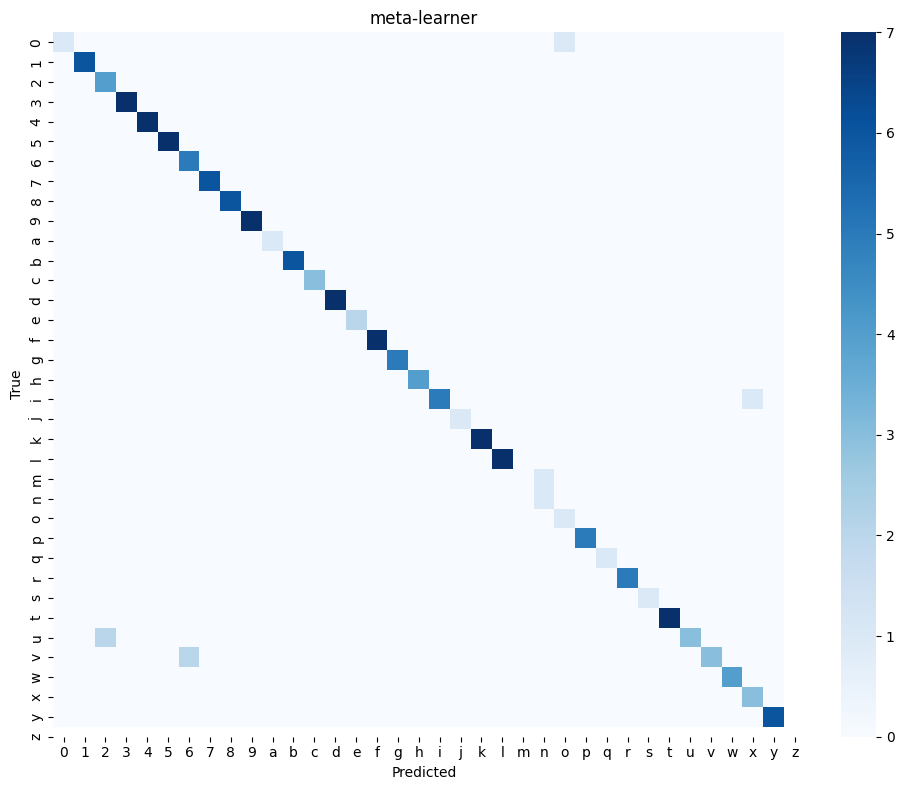

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       1.00      1.00      1.00         6
           2       0.67      1.00      0.80         4
           3       1.00      1.00      1.00         7
           4       1.00      1.00      1.00         7
           5       1.00      1.00      1.00         7
           6       0.71      1.00      0.83         5
           7       1.00      1.00      1.00         6
           8       1.00      1.00      1.00         6
           9       1.00      1.00      1.00         7
           a       1.00      1.00      1.00         1
           b       1.00      1.00      1.00         6
           c       1.00      1.00      1.00         3
           d       1.00      1.00      1.00         7
           e       1.00      1.00      1.00         2
           f       1.00      1.00      1.00         7
           g       1.00      1.00      1.00         5
           h       1.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

(0.9556962025316456, 0.9114162028447743)

In [18]:
def evaluate_predictions(preds: np.ndarray, labels: np.ndarray, name: str,
                          class_names=None, plot_cm=False):
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    print(f"{name:>28s} | acc={acc:.4f}  macro-F1={f1:.4f}")
    if plot_cm and class_names is not None:
        cm = confusion_matrix(labels, preds)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=False, cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names)
        plt.title(name)
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()
        # Fix: explicitly pass the 'labels' parameter to classification_report
        print(classification_report(labels, preds, target_names=class_names, labels=list(range(len(class_names)))))
    return acc, f1

print("\n=== Test-set comparison (same held-out samples for all) ===")
for name, logits in test_logits.items():
    preds = logits.argmax(1).numpy()
    evaluate_predictions(preds, test_labels_np, f"single model: {name}")

avg_preds = average_logits_fusion(test_logits)
evaluate_predictions(avg_preds, test_labels_np, "stacking: average logits")

conf_preds = confidence_weighted_fusion(test_logits)
evaluate_predictions(conf_preds, test_labels_np, "stacking: confidence-weighted")

meta_preds = meta_learner_predict(meta_model, test_logits)
evaluate_predictions(meta_preds, test_labels_np, "meta-learner",
                      class_names=classes, plot_cm=True)